В этом блокноте с помощью аппроксимации экспериментальной кривой коэффициента отражения рассчитывается реальная и мнимая части диэлектрической проницаемости графеновых пленок разной толщины. Суть процедуры аппроксимации: 
1) по МНК или "вручную" найти угол резонанса по InSb, считая диэлектрическую проницаемость известной
2) найти сдвиг между экспериментальным и теоретическим минимумом InSb, сместить начало обеих осей x на это расстояние
3) аппроксимируя кривую графена по известному значению угла и сдвига, найти реальную и мнимую части д.п. графена


Вопросы:
1) обоснование выбора участка суммирования: оценить влияние дифракции (систематическую погрешность), оптимальный отступ от границы; попробовать разные участки
2) учёт тензорного характера д.п. графена
3) корректна ли аппроксимация, если резонанс сильно зависит от угла, который из-за дифракции определяется с точностью до десятых градуса; построить график ковариации от д.п., возможно есть смысл разобраться в алгоритмах optimize.curve()
4) по какому участку графика фитировать
5) почему ширина графиков InSb (и угол резонанса?) зависит от толщины графена (сдвиг может зависеть)
6) протестировать метод на InSb, одновременно фитировать его д.п., угол и сдвиг, сравнить д.п. с табличной;
7) протестировать 1 образец дважды, чтобы исключить случайную погрешность (помимо колебаний IMO, которые учтены нормировкой R)
8) какая ошибка в определении нуля гониометра и линейки?

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sympy

In [2]:
# Load data using configurable paths
# Output files are created in file aperture.ipynb

# Function to load data from file
def load_data(file_path):
    return pd.read_csv(file_path, sep='\t', decimal=',')

base_path = r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers'

file_paths = {
    'data_3_5_along': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_along_3_5_full.ascii'),
    'data_3_5_trans': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_trans_3_5_full.ascii'),
    'data_6_along': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_along_6_full.ascii'),
    'data_6_trans': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_trans_6_full.ascii'),
    'data_12_along': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_along_12_full.ascii'),
    'data_12_trans': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_trans_12_full.ascii')
}

data_3_5_along = load_data(file_paths['data_3_5_along'])
data_3_5_trans = load_data(file_paths['data_3_5_trans'])
data_6_along = load_data(file_paths['data_6_along'])
data_6_trans = load_data(file_paths['data_6_trans'])
data_12_along = load_data(file_paths['data_12_along'])
data_12_trans = load_data(file_paths['data_12_trans'])

In [ ]:
# Совет от GPT по обращению с глобальными переменными: ......

n_prism = complex(1.531, -0.002)                   # комплексный показатель преломления призмы Zeonex
eps_prism = n_prism**2                             # диэлектрическая проницаемость призмы Zeonex
eps_air = n = 1                                    # диэлектрическая проницаемость воздуха (1.00027717)
eps_InSb = complex(-17.3, 7.12)                    # InSb на 197мкм табличное значение
wavelength = 197 * 10**(-6)                        # длина волны лазера в метрах
d_layer = 35 * 10**(-9)                            # толщина графеновой плёнки в метрах
step = 0.083*10**(-6)                              # шаг в метрах

# -18+0.0066j - InSb по Друде-Лоренцу
#  - графен 35 нм по Друде-Лоренцу
# - графен 35 нм из отчёта В.В.


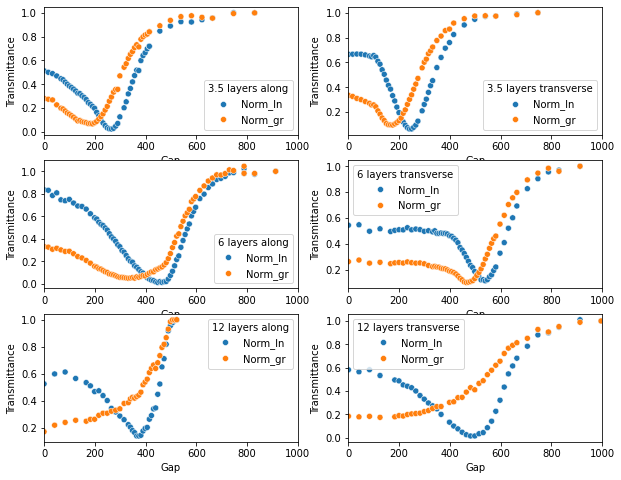

In [4]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8), ) 

al_3_5_melted = data_3_5_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers along', value_name='Transmittance')
sns.scatterplot(data = al_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers along", ax=axs[0, 0])
tr_3_5_melted = data_3_5_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers transverse", ax=axs[0, 1])
al_6_melted = data_6_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers along', value_name='Transmittance')
sns.scatterplot(data = al_6_melted, x="Gap", y="Transmittance", hue="6 layers along", ax=axs[1, 0])
tr_6_melted = data_6_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_6_melted, x="Gap", y="Transmittance", hue="6 layers transverse", ax=axs[1, 1])
al_12_melted = data_12_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers along', value_name='Transmittance')
sns.scatterplot(data = al_12_melted, x="Gap", y="Transmittance", hue="12 layers along", ax=axs[2, 0])
tr_12_melted = data_12_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_12_melted, x="Gap", y="Transmittance", hue="12 layers transverse", ax=axs[2, 1])
for ax in plt.gcf().axes:
    ax.set_xlim(0, 1000)
plt.show()

# изменить ось x


In [5]:
# Расчёт угла падения на внутреннюю грань на по углу падения пучка на внешние грани призмы
def teta_from_ext(teta_ext):
    teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))
    return teta

In [6]:
# define reflect3 by V.V.'s code


# d_2 - air gap, teta - internal incidence angle, eps_3 - permittivity of 3rd medium (InSb)
def reflect3(d_2, teta, eps3_re, eps3_im, wavelength = 197 * 10**(-6)):

    n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
    eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)       
    eps_2 = 1  # Dielectric permittivity of air
    eps_3 = eps3_re + eps3_im*1j
    
    # Normal components of wave vectors (normalized by k0)
    kz_1 = np.sqrt(eps_1) * np.cos(teta)
    kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
    kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)

    # Reflection coefficients
    r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)

    # Transmission coefficients
    t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)

    # Transformation matrix
    S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])

    R = np.zeros(len(d_2))  # Initialize reflection coefficient array

    for j in range(len(d_2)):
        S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                    [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]], dtype=np.complex128)
        
        S = np.dot(S1, S2)
        R[j] = (np.abs(S[1, 0] / S[0, 0]))**2

    return R

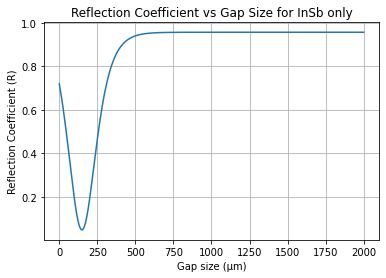

In [7]:
# Vizualize reflect3

d_2 = np.arange(0, 2000 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb
teta = 0.7334459774574046
eps3_re, eps3_im = (-16.999358675469676, 7.112859392867092)
params = [d_2, teta, eps3_re, eps3_im]
R = reflect3(*params)

# Plot the results
plt.plot(d_2 * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size for InSb only')
plt.grid()
plt.show()

In [8]:
# define reflect4 by V.V.'s code


def reflect4(d_2, d_3, teta, eps3_re, eps3_im, eps4_re, eps4_im, wavelength = 197 * 10**(-6)): # teta - internal incidence angle,  d_2 - gap, d_3 - Gr, eps_re/im - gr
    
    n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
    eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
    eps_2 = 1  #Dielectric permittivity of air"
    eps_3 = eps3_re+eps3_im*1j
    eps_4 = eps4_re+eps4_im*1j

    # Normal components of wave vectors (normalized by k0)
    kz_1 = np.sqrt(eps_1) * np.cos(teta)
    kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
    kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
    kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

    # Reflection coefficients
    r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transmission coefficients
    t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transformation matrices
    S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
    S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                    [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

    R = np.zeros(len(d_2))  # Initialize reflection coefficient array

    for j in range(len(d_2)):
        S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                        [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]], dtype=np.complex128)
        
        S = S1 @ S2 @ S3  # Matrix multiplication
        R[j] = (np.abs(S[1, 0] / S[0, 0]))**2
    
    return R


   

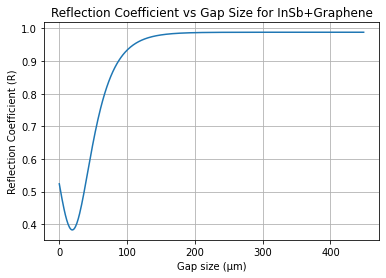

In [9]:
# Visualize reflect4

d_2 = np.arange(0, 450*10**(-6), 10**(-6))  # Gap size between the prism and InSb (microns)
d_3 = 35 * 10**(-9)  # Thickness of the studied layer 
teta = 0.8672552397697336
eps3_re, eps3_im = (-14, 700)

# Dielectric permittivity of the thin dielectric layer on InSb
eps4_re, eps4_im = (-16.999299592080213, 7.106286644764289)
R = reflect4(d_2, d_3, teta, eps3_re, eps3_im, eps4_re, eps4_im)

# Plot the results
plt.plot(d_2*10**(6), R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size for InSb+Graphene')
plt.grid()
plt.show()

In [ ]:
# подгонка угла, сдвига и (возможно) д.п. InSb по InSb
def fitting_function(x, shift, angle, re_InSb, im_InSb):
    return reflect3(x - np.ones(x.size, dtype=np.float64) * shift, angle, re_InSb, im_InSb)

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans, data_12_along, data_12_trans]

# Range of fitting (number of right/left points from minimum of R)
high_bound = 20
low_bound = 5

# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values.astype(np.float64) * 1e-6
    norm_in = df['Norm_In'].values.astype(np.float64)

    # Dynamic initial guesses based on data statistics
    shift_guess = 1e-6
    angle_guess = 7.35759925e-01  # Keeping as a constant guess, or adjust based on context
    re_InSb_guess = -9
    im_InSb_guess = 9
    initial_guess = [shift_guess, angle_guess, re_InSb_guess, im_InSb_guess]
    my_bounds = ([0, (7.35759925e-01)-(1e-10), -9-5, 9-5], [1e-3, (7.35759925e-01)+(1e-10), -9+5, 9+5])
    #([0, 1e-3],[0.6, 0.8], [-18, -16], [6, 8])


    # Ensure min_index and max_index are within bounds
    min_index = max(norm_in.argmin() - low_bound, 0)
    max_index = min(norm_in.argmin() + high_bound, len(gap))
    
    try:
        params, pcov , infodict , mesg , ier = curve_fit(fitting_function, gap[min_index:max_index], norm_in[min_index:max_index], p0=initial_guess, bounds=my_bounds, method='trf', full_output=True)
        print(params, pcov , infodict , mesg , ier)
    except RuntimeError as e:
        print(f"Fitting failed for Dataframe {i+1}: {e}")
        params = initial_guess

    # Validate params before using them in the fitting function
    if not np.any(np.isnan(params)) and not np.any(np.isinf(params)):
        # Plot the original data
        axes[i].scatter(gap*1e6, norm_in, color='blue', label='Norm_In', s=5, alpha=0.6)

        # Plot the fitted function
        fitted_values = fitting_function(gap, *params)
        if not np.any(np.isnan(fitted_values)) and not np.any(np.isinf(fitted_values)):
            axes[i].plot(gap*1e6, fitted_values, color='red', label='Fitted reflect3(Gap)')
        else:
            print(f"Invalid fitted values for Dataframe {i+1}, skipping plot.")
    else:
        print(f"Invalid fitting parameters for Dataframe {i+1}, skipping plot.")

    # Set subplot title and labels
    axes[i].set_title(f'Dataframe {i+1}')
    axes[i].set_xlabel('Gap [mkm]')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()  



In [ ]:
# Угол резонанса - из 1 графика (3.5 слой along), т.к. лучше аппроксимация
# На остальных графиках аппроксимация УЖАСНАЯ, хотя InSb графики должны СОВПАДАТЬ с точностью до сдвига

7.28050201e-01

[ 7.59362718e-05 -1.73652126e+01  1.54573263e+01] [[2.59352829e-02 7.33066619e+03 4.91923588e+03]
 [7.33066619e+03 2.07202933e+09 1.39043311e+09]
 [4.91923588e+03 1.39043311e+09 9.33048685e+08]] {'nfev': 22, 'fvec': array([ 0.05229159,  0.02730576,  0.00733751, -0.00177501, -0.01267923,
       -0.01116214, -0.01585139, -0.01552167, -0.01615583, -0.01127607,
       -0.00370039, -0.00059034,  0.00589332,  0.00262213,  0.00923649,
        0.01003882,  0.03005525,  0.06952173, -0.00380896, -0.00192459,
        0.00252801, -0.00985361, -0.01425843, -0.00934129, -0.01737556])} `xtol` termination condition is satisfied. 3
[ 4.25775050e-05 -2.12250555e+01  1.64058107e+01] [[1.25365843e-02 3.21931646e+03 2.80787185e+03]
 [3.21931646e+03 8.26700332e+08 7.21043930e+08]
 [2.80787185e+03 7.21043930e+08 6.28890940e+08]] {'nfev': 20, 'fvec': array([-0.02315103, -0.02325791, -0.01380996, -0.01230637, -0.01239795,
       -0.00568362, -0.0022581 ,  0.00378557,  0.01213028,  0.01999438,
        0.0133855

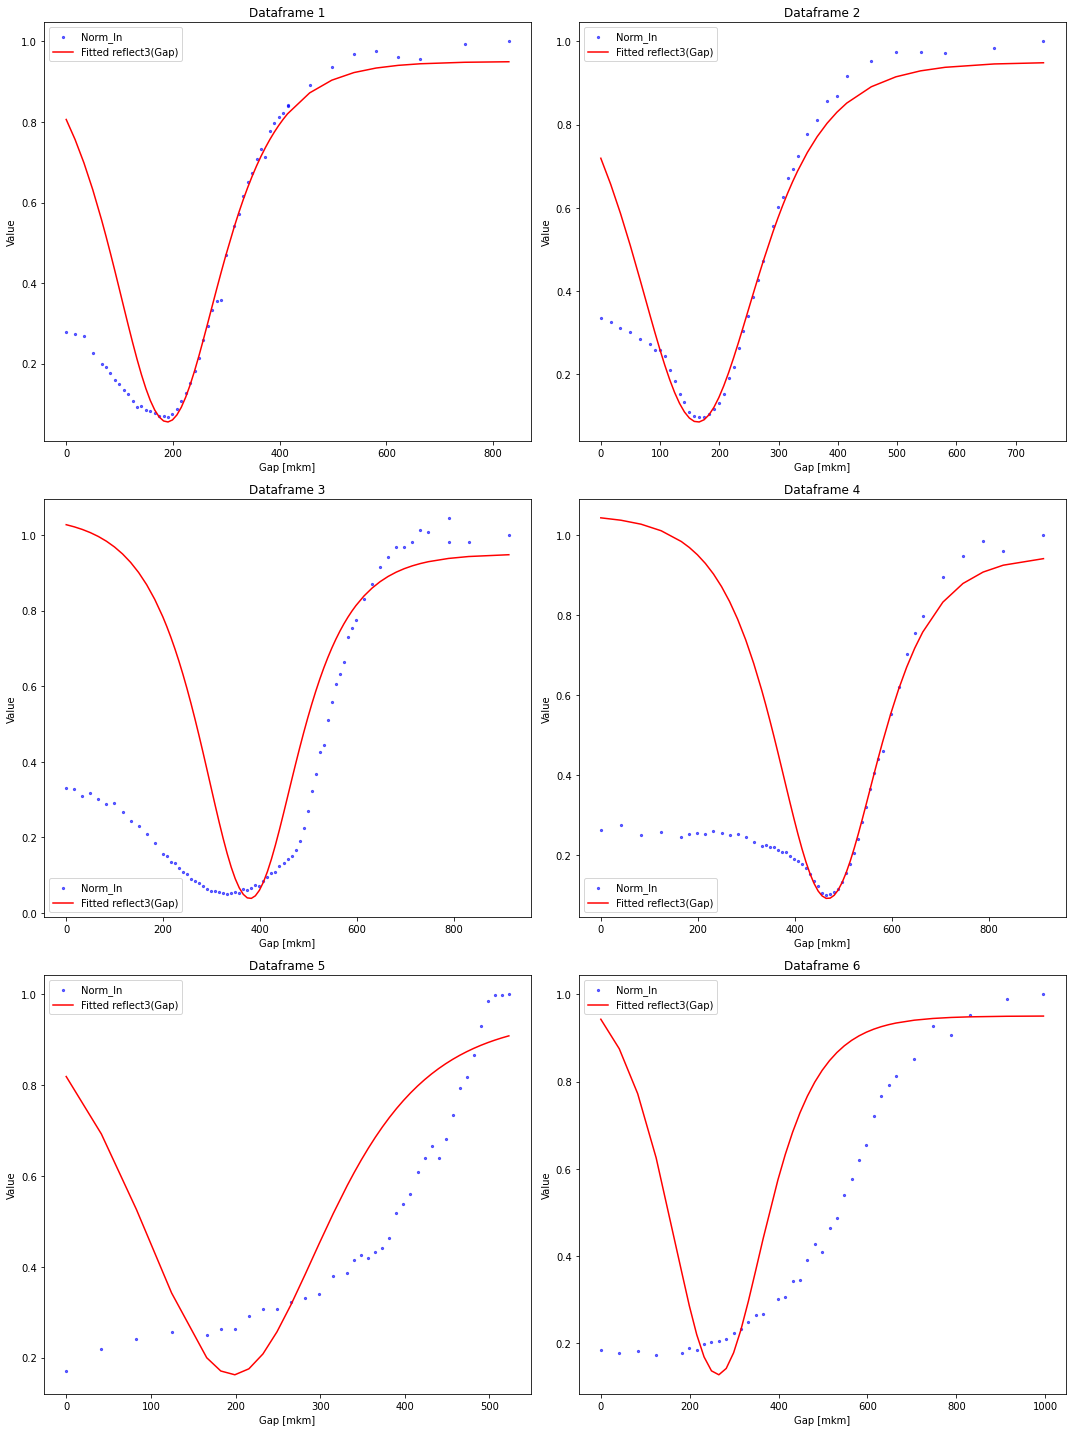

In [43]:
# Fitting permittivity of graphene

# подгонка угла, сдвига и (возможно) д.п. InSb по InSb


# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans, data_12_along, data_12_trans]
thickness = np.array([3.5, 3.5, 6, 6, 12, 12])*10**(-6)

# Range of fitting (number of right/left points from minimum of R)
high_bound = 20
low_bound = 5

# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values.astype(np.float64) * 1e-6
    norm_in = df['Norm_gr'].values.astype(np.float64)

    def fitting_function(x, shift, eps3_re, eps3_im):
        return reflect4(x - np.ones(x.size, dtype=np.float64) * shift, d_3 = thickness[i], teta = 7.28050201e-01, eps3_re=eps3_re, eps3_im=eps3_im, eps4_re=-9, eps4_im=9)

    # Dynamic initial guesses based on data statistics
    shift_guess = 1e-6
    re_Gr_guess = -9
    im_Gr_guess = 9
    initial_guess = [shift_guess, re_Gr_guess, im_Gr_guess]
    my_bounds = ([0,  -np.inf, 0], [1e-3, 0, np.inf])
    #([0, 1e-3],[0.6, 0.8], [-18, -16], [6, 8])


    # Ensure min_index and max_index are within bounds
    min_index = max(norm_in.argmin() - low_bound, 0)
    max_index = min(norm_in.argmin() + high_bound, len(gap))
    
    try:
        params, pcov , infodict , mesg , ier = curve_fit(fitting_function, gap[min_index:max_index], norm_in[min_index:max_index], p0=initial_guess, bounds=my_bounds, method='trf', full_output=True)
        print(params, pcov , infodict , mesg , ier)
    except RuntimeError as e:
        print(f"Fitting failed for Dataframe {i+1}: {e}")
        params = initial_guess

    # Validate params before using them in the fitting function
    if not np.any(np.isnan(params)) and not np.any(np.isinf(params)):
        # Plot the original data
        axes[i].scatter(gap*1e6, norm_in, color='blue', label='Norm_In', s=5, alpha=0.6)

        # Plot the fitted function
        fitted_values = fitting_function(gap, *params)
        if not np.any(np.isnan(fitted_values)) and not np.any(np.isinf(fitted_values)):
            axes[i].plot(gap*1e6, fitted_values, color='red', label='Fitted reflect3(Gap)')
        else:
            print(f"Invalid fitted values for Dataframe {i+1}, skipping plot.")
    else:
        print(f"Invalid fitting parameters for Dataframe {i+1}, skipping plot.")

    # Set subplot title and labels
    axes[i].set_title(f'Dataframe {i+1}')
    axes[i].set_xlabel('Gap [mkm]')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()  




In [ ]:
gap_arr = x_data
print(x_data) 
plt.plot(gap_arr, reflect3(gap_arr, 0.72889286))
plt.plot(gap_arr, y_data)
plt.show()

In [ ]:
a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p = sp.symbols(
    'a b c d e f g h i j k l m n o p'
)

# Define matrices A, B, C, and D
A = sp.Matrix([[a, b], [c, d]])
B = sp.Matrix([[e, f], [g, h]])
C = sp.Matrix([[i, j], [k, l]])
D = sp.Matrix([[m, n], [o, p]])

# Perform symbolic matrix multiplication (A * B) * C * D
result = (A * B) * C * D

# Display the result
result